## Alpha vs Beta Clone/Fidelity Comparison

### Generate 30-clone alpha/beta distributions
These distributions are generated with `clone_creator.py` and then shaped so the
pilot-fidelity performance has the requested profiles (alpha: diverse/stepwise;
beta: smooth/gradual).


In [15]:
import tempfile
from pathlib import Path

import numpy as np

import mfbo4bio.conditions_data as data
from mfbo4bio import clone_creator

N_CLONES = 30
ALPHA_SEED = 101
BETA_SEED = 202


def _rename_mu_key(params):
    for _, values in params.items():
        if "my_max" in values and "mu_max" not in values:
            values["mu_max"] = values.pop("my_max")
    return params


def _generate_base_params(seed: int):
    tmp_path = Path(tempfile.gettempdir()) / f"clone_params_{seed}.py"
    params = clone_creator.generate_process_parameters(
        n_celltypes=N_CLONES,
        seed=seed,
        filename=str(tmp_path),
    )
    return _rename_mu_key(params)


def _apply_mu_scaling(params, scale_profile):
    celltypes = sorted(
        params.keys(),
        key=lambda name: int(name.split("_")[-1]),
    )
    for celltype, scale in zip(celltypes, scale_profile):
        params[celltype]["mu_max"] *= scale
    return params



def _stepped_values(total, steps, start, end):
    steps = max(1, int(steps))
    total = max(1, int(total))
    step_sizes = np.full(steps, total // steps, dtype=int)
    step_sizes[: total % steps] += 1
    step_values = np.linspace(start, end, steps).tolist()
    profile = []
    for size, value in zip(step_sizes, step_values):
        profile.extend([value] * int(size))
    return profile


def _stepped_profile(
    n,
    top_frac=0.30,
    top_steps=3,
    low_steps=6,
    hi_range=(1.25, 1.55),
    lo_range=(0.70, 1.05),
):
    top_n = max(1, int(round(n * top_frac)))
    remainder = n - top_n
    hi_profile = _stepped_values(top_n, top_steps, hi_range[1], hi_range[0])
    lo_profile = _stepped_values(remainder, low_steps, lo_range[1], lo_range[0])
    return hi_profile + lo_profile

alpha_profile = _stepped_profile(

    N_CLONES,

    top_frac=0.30,

    top_steps=3,

    low_steps=6,

    hi_range=(1.25, 1.55),

    lo_range=(0.70, 1.05),

)


t = np.linspace(0, 1, N_CLONES)
beta_profile = (0.9 + 0.05 * np.power(t, 0.15)).tolist()


alpha_params = _apply_mu_scaling(_generate_base_params(ALPHA_SEED), alpha_profile)
beta_params = _apply_mu_scaling(_generate_base_params(BETA_SEED), beta_profile)

data.process_parameters_alpha = alpha_params
data.process_parameters_beta = beta_params


Saved nicely formatted process_parameters to '/var/folders/7m/z4zzcyjd7bqdqcv5y_z08b640000gn/T/clone_params_101.py'
Saved nicely formatted process_parameters to '/var/folders/7m/z4zzcyjd7bqdqcv5y_z08b640000gn/T/clone_params_202.py'


Saved: /Users/adrianmartens/Documents/BA/PAPER/mfbo4bio/plots_pdf/alpha_beta_clone_fidelity_comparison.pdf


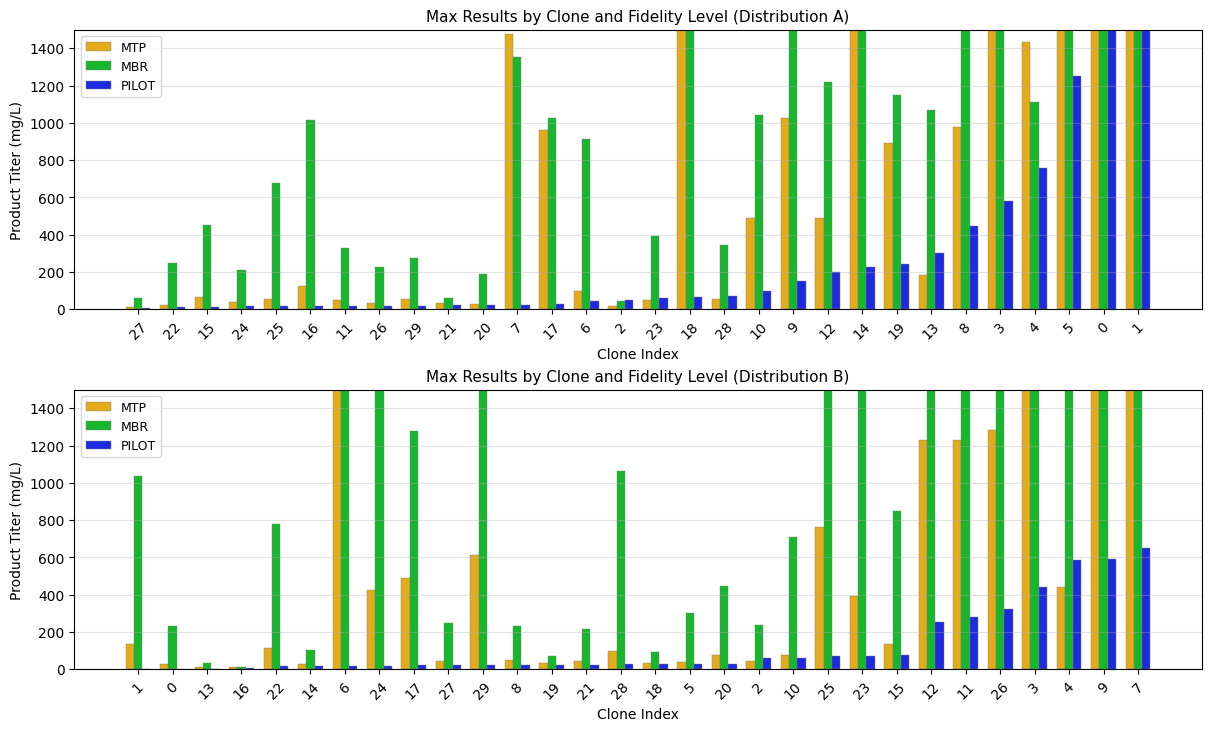

In [17]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

import mfbo4bio.conditions_data as data
from mfbo4bio import virtual_lab as vl
from mfbo4bio.results import project_root
from mfbo4bio.utils import sampling

SEED = 12
NUM_SAMPLES = 1000
FEEDING_MAX = 50
FIDELITY_LEVELS = [0, 7, 10]
FIDELITY_DISTRIBUTION = {0: 0.4, 7: 0.4, 10: 0.2}
COLORS = {0: "#E3AA1A", 7: "#16B72C", 10: "#1E2AE0"}
LABELS = {0: "MTP", 7: "MBR", 10: "PILOT"}
SAVE_PDF = True
PDF_NAME = "alpha_beta_clone_fidelity_comparison.pdf"
PDF_DIR = project_root() / "plots_pdf"


def _n_clones_for_distribution(dist_name: str) -> int:
    attr_name = f"process_parameters_{dist_name}"
    if hasattr(data, attr_name):
        return len(getattr(data, attr_name).keys())

    # Fallback for older data modules
    if hasattr(data, "process_parameters"):
        return len(data.process_parameters.keys())

    raise AttributeError(
        f"No process parameter mapping found for "
        f"distribution '{dist_name}'."
    )


def _simulate_distribution(dist_name: str):
    n_clones = _n_clones_for_distribution(dist_name)

    dimensions_dict = {
        "temperature": ("continuous", (30, 40)),
        "ph": ("continuous", (6.0, 8.0)),
        "feeding1": ("continuous", (0, FEEDING_MAX)),
        "feeding2": ("continuous", (0, FEEDING_MAX)),
        "feeding3": ("continuous", (0, FEEDING_MAX)),
        "fidelity": ("discrete", FIDELITY_LEVELS),
        "clone": ("discrete", list(range(n_clones))),
    }

    constraints = {
        "feeding_max": FEEDING_MAX,
        "feeding_dims": ["feeding1", "feeding2", "feeding3"],
    }

    inputs = sampling(
        method="latin_hypercube",
        dimensions_dict=dimensions_dict,
        num_samples=NUM_SAMPLES,
        constraints=constraints,
        fidelity_distribution=FIDELITY_DISTRIBUTION,
        seed=SEED,
    )

    outputs = vl.conduct_experiment(inputs, clone_distribution=dist_name)

    if hasattr(inputs, "detach"):
        inputs_np = inputs.detach().cpu().numpy()
    else:
        inputs_np = np.asarray(inputs)
    if hasattr(outputs, "detach"):
        outputs_np = outputs.detach().cpu().numpy()
    else:
        outputs_np = np.asarray(outputs)

    return inputs_np, outputs_np


def _max_by_clone_and_fidelity(inputs_np: np.ndarray, outputs_np: np.ndarray):
    grouped = defaultdict(list)
    for x, y in zip(inputs_np, outputs_np):
        clone = int(x[6])
        fidelity = int(x[5])
        grouped[(clone, fidelity)].append(float(y))

    all_clones = sorted({clone for (clone, _) in grouped.keys()})
    clone_pilot_max = {
        clone: np.max(grouped.get((clone, 10), [0.0]))
        for clone in all_clones
    }
    sorted_clones = sorted(all_clones, key=lambda c: clone_pilot_max[c])

    maxima = {
        fidelity: [
            np.max(grouped.get((clone, fidelity), [0.0]))
            for clone in sorted_clones
        ]
        for fidelity in FIDELITY_LEVELS
    }
    return sorted_clones, maxima


def _plot_distribution(ax, dist_name: str, sorted_clones, maxima):
    x = np.arange(len(sorted_clones))
    width = 0.24
    offsets = {0: -width, 7: 0.0, 10: width}

    for fidelity in FIDELITY_LEVELS:
        ax.bar(
            x + offsets[fidelity],
            maxima[fidelity],
            width=width,
            label=LABELS[fidelity],
            color=COLORS[fidelity],
            edgecolor="gray",
            linewidth=0.3,
        )

    label_suffix = "A" if dist_name == "alpha" else "B"

    max_value = max(max(maxima[fidelity]) for fidelity in FIDELITY_LEVELS)
    if max_value > 400:
        ax.set_ylim(0, 1500)

    ax.set_title(
        f"Max Results by Clone and Fidelity Level "
        f"(Distribution {label_suffix})",
        fontsize=11,
    )
    ax.set_ylabel("Product Titer (mg/L)")
    ax.set_xticks(x)
    ax.set_xticklabels(sorted_clones, rotation=45)
    ax.set_xlabel("Clone Index")
    ax.grid(axis="y", alpha=0.35)
    ax.legend(loc="upper left", fontsize=9)


alpha_inputs, alpha_outputs = _simulate_distribution("alpha")
beta_inputs, beta_outputs = _simulate_distribution("beta")

alpha_sorted_clones, alpha_maxima = _max_by_clone_and_fidelity(
    alpha_inputs, alpha_outputs
)
beta_sorted_clones, beta_maxima = _max_by_clone_and_fidelity(beta_inputs, beta_outputs)

fig, axes = plt.subplots(2, 1, figsize=(12, 7.2), constrained_layout=True)
_plot_distribution(axes[0], "alpha", alpha_sorted_clones, alpha_maxima)
_plot_distribution(axes[1], "beta", beta_sorted_clones, beta_maxima)

if SAVE_PDF:
    PDF_DIR.mkdir(parents=True, exist_ok=True)
    out_path = Path(PDF_DIR) / PDF_NAME
    fig.savefig(out_path, format="pdf", bbox_inches="tight")
    print(f"Saved: {out_path}")

plt.show()